In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scipy import stats

import jax
import jax.numpy as jnp
import optax

from local_utils.delaunay import PpopDelaunay, sample_p_pop

plt.style.use("tableau-colorblind10")


In [2]:
def compute_empirical_quantiles(sampled_points, quantiles):

    sampled_points = sampled_points[~jnp.isnan(sampled_points).any(axis=1)]
    
    shift = sampled_points - gt_distro.mean
    precision_matrix = np.linalg.inv(gt_distro.cov_object.covariance)
    mahalanobis_squared = np.einsum("ij,jk,ki->i", shift, precision_matrix, shift.T)

    thresholds = stats.chi2(df=sampled_points.shape[1]).ppf(quantiles)

    return (mahalanobis_squared < thresholds[:, None]).sum(
        axis=1
    ) / mahalanobis_squared.size


In [3]:
gt_distro = stats.multivariate_normal([0, 0], [[1.2, 0.9], [0.9, 1]])

num_events = 100_000

event_points = jnp.array(gt_distro.rvs(num_events))
true_vals = gt_distro.logpdf(event_points)

p_pop = PpopDelaunay(
    event_points,
    triangulation_points=50,
    num_norm_points=100_000,
    norm_key=jax.random.key(41938),
)


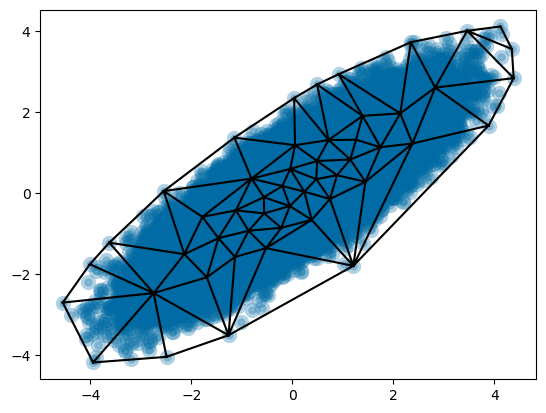

In [4]:
fig, ax = plt.subplots()
ax.scatter(event_points[:, 0], event_points[:, 1], alpha=0.3, lw=5)

ax.triplot(
    p_pop.triangulation.points[:, 0],
    p_pop.triangulation.points[:, 1],
    p_pop.triangulation.simplices,
    color="black",
)


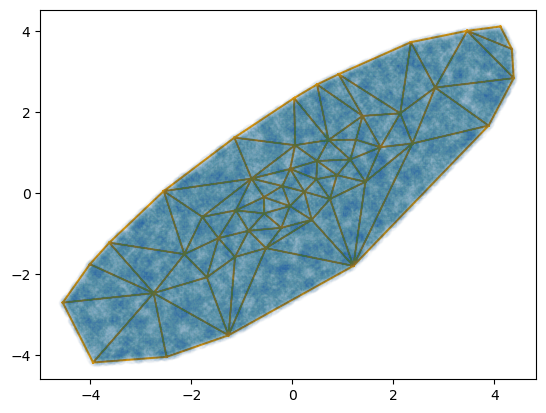

In [5]:
key = jax.random.key(123928)
key, subkey = jax.random.split(key)
chosen_simplices, barycentric = p_pop.sample_uniformly_within_hull(subkey, 50_000)

cartesian_coords = (
    barycentric[:, :, None] * p_pop.simplex_vertices_coords[chosen_simplices]
).sum(axis=1)

fig, ax = plt.subplots()
ax.plot(*cartesian_coords.T, "o", alpha=0.01)

ax.triplot(
    p_pop.triangulation.points[:, 0],
    p_pop.triangulation.points[:, 1],
    p_pop.triangulation.simplices,
    color="orange",
)


In [6]:
@jax.jit
def cost(weights):
    return -p_pop.log_prob(weights)


@jax.jit
def train_step(weights, opt_state):
    grads = jax.grad(cost)(weights)
    updates, opt_state = optimizer.update(grads, opt_state)
    return optax.apply_updates(weights, updates), opt_state


key = jax.random.key(1212386323)

key, subkey = jax.random.split(key)
weights = jax.random.normal(subkey, p_pop.triangulation_points)

optimizer = optax.adam(1)
opt_state = optimizer.init(weights)
for _ in range(1_00):
    weights, opt_state = train_step(weights, opt_state)


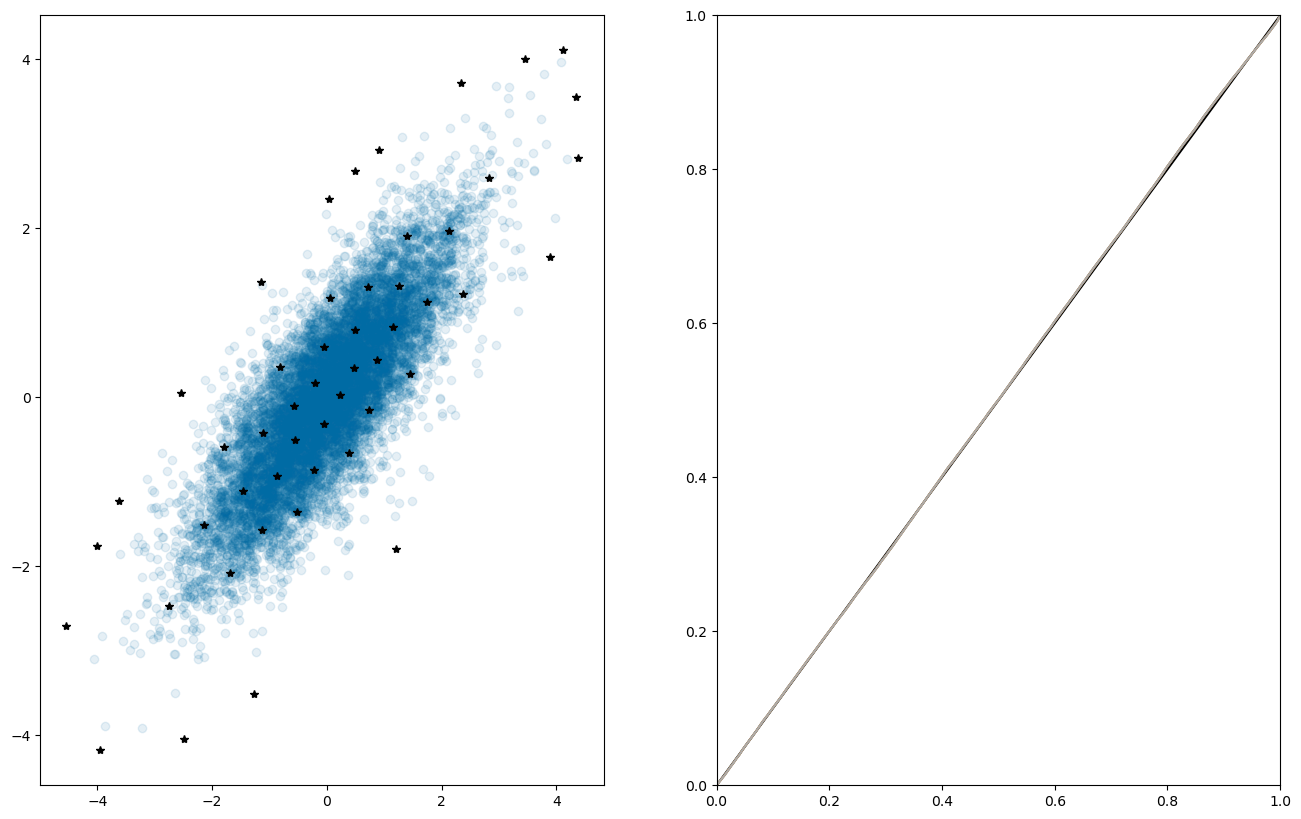

In [7]:
quantiles = np.linspace(0, 1, 2_00)
Qs = [
    compute_empirical_quantiles(sample_p_pop(key, 1_000_000, p_pop, weights), quantiles)
    for _ in range(10)
]
les_quantiles = np.quantile(Qs, [0, 0.5, 1], axis=0)

fig, axs = plt.subplots(1, 2, figsize=(16, 10))

ax = axs[0]
ax.scatter(*sample_p_pop(key, 100_000, p_pop, weights).T, alpha=0.1)
ax.plot(*p_pop.triangulation.points.T, "*", color="black")

ax = axs[1]
ax.set(xlim=(0, 1), ylim=(0, 1))
ax.axline((0, 0), slope=1, color="black")
for ind in range(les_quantiles.shape[0]):
    ax.plot(quantiles, les_quantiles[ind])

plt.show()
plt.close()


In [13]:
weights_std = weights.std()
print(weights_std)

num_proposals = 10_000
propose_weights = weights + 0.01 * weights_std * (
    1 - 2 * np.random.rand(num_proposals, weights.size)
)

key, subkey = jax.random.split(key)
proposal_log_prob = jax.vmap(p_pop.log_prob, in_axes=0, out_axes=0)(propose_weights)
accepted_weights = propose_weights[
    jnp.log(jax.random.uniform(subkey, shape=num_proposals))
    < proposal_log_prob - p_pop.log_prob(weights)
]
print(accepted_weights.shape)


3.1399057
(21, 50)


In [14]:
quantiles = np.linspace(0, 1, 2_00)

Qs = np.zeros((10, quantiles.size))
for ind in range(Qs.shape[0]):
    key, subkey = jax.random.split(key)
    Qs[ind] = compute_empirical_quantiles(
        sample_p_pop(subkey, 1_000_000, p_pop, accepted_weights[ind], ), quantiles
    )


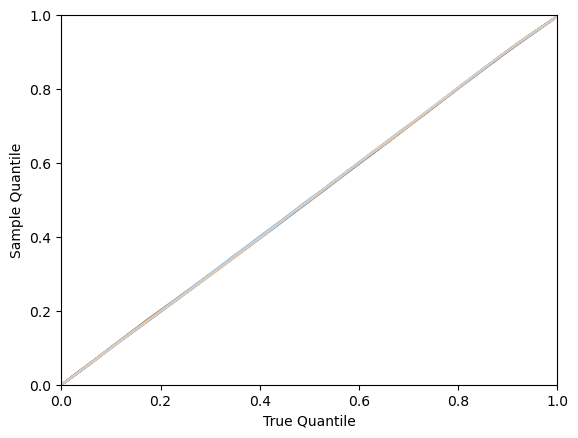

In [15]:
fig, ax = plt.subplots()
ax.set(xlabel="True Quantile", ylabel="Sample Quantile", xlim=(0, 1), ylim=(0, 1))
for line in Qs:
    ax.plot(quantiles, line)
